# Introdução
**Exemplo de análise de Regressão Logística referente a empréstimos**

**Base de dados púlica disponível no Kaggle**

**Análise feita por Lucas Gabriel Winter**

**O código foi todo comentado para facilitar o entendimento (pt-br)**

In [1]:
#importações das bibliotecas necessárias
# dados
import pandas as pd
import numpy as np


# visualização
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import plotly.express as px
import plotly.figure_factory as ff
import plotly.graph_objects as go
from wordcloud import WordCloud

# estilos
%matplotlib inline
sns.set_style('darkgrid')
mpl.rcParams['font.size'] = 14
mpl.rcParams['figure.facecolor'] = '#00000000'
mpl.rcParams['font.size'] = 14
mpl.rcParams['figure.facecolor'] = '#00000000'

import os
from wordcloud import WordCloud

import warnings
warnings.filterwarnings("ignore")

**Realizando a leitura dos dados do arquivo CSV e organizando as variáveis**

In [2]:
#importação dos dados do arquivo csv
dados = pd.read_csv('/kaggle/input/credit-risk-dataset/credit_risk_dataset.csv')

In [3]:
#utilização de cinco casas decimais para simplicação de visualização
pd.set_option('display.float_format', '{:.5f}'.format)
#mostra todas as colunas na visualização
pd.set_option('display.max_columns', None)

**Traduzindo o nome das variáveis**

In [4]:
#nome das novas variáveis em português
mapeamento_variaveis = {
    'person_age': 'idade_individuo',
    'person_income': 'renda_anual_individuo',
    'person_home_ownership': 'tipo_posse_imovel',
    'person_emp_length': 'tempo_emprego_anos',
    'loan_intent': 'proposito_emprestimo',
    'loan_grade': 'classificacao_emprestimo',
    'loan_amnt': 'valor_emprestimo',
    'loan_int_rate': 'taxa_juros_emprestimo',
    'loan_status': 'status_emprestimo',
    'loan_percent_income': 'percentual_renda_emprestimo',
    'cb_person_default_on_file': 'historico_inadimplencia',
    'cb_person_cred_hist_length': 'duracao_historico_credito'
}

In [5]:
#trocando o nome das variáveis
dados.rename(columns=mapeamento_variaveis, inplace=True)

In [6]:
# Traduzindo e substituindo as categorias da variável tipo_posse_imovel
mapeamento_categorias_imovel = {
    'RENT': 'aluguel',
    'OWN': 'imovel_proprio',
    'MORTGAGE': 'imovel_financiado',
    'OTHER': 'imovel_outros'
}

dados['tipo_posse_imovel'] = dados['tipo_posse_imovel'].replace(mapeamento_categorias_imovel)

In [7]:
# Traduzindo e substituindo as categorias da variável proposito_emprestimo
mapeamento_categorias_proposito = {
    'DEBTCONSOLIDATION': 'fins_consolidacao_debito',
    'EDUCATION': 'fins_educacao',
    'MEDICAL': 'fins_medicos',
    'PERSONAL': 'fins_pessoais',
    'VENTURE': 'fins_negocios',
    'HOMEIMPROVEMENT': 'fins_reformas'
}


dados['proposito_emprestimo'] = dados['proposito_emprestimo'].replace(mapeamento_categorias_proposito)

In [8]:
# Traduzindo e substituindo as categorias da variável classificacao_emprestimo
mapeamento_categorias_classificacao = {
    'A': 'classificacao_A',
    'B': 'classificacao_B',
    'C': 'classificacao_C',
    'D': 'classificacao_D',
    'E': 'classificacao_E',
    'F': 'classificacao_F',
    'G': 'classificacao_G'
}


dados['classificacao_emprestimo'] = dados['classificacao_emprestimo'].replace(mapeamento_categorias_classificacao)

In [9]:
# Traduzindo e substituindo as categorias da variável historico_inadimplencia
mapeamento_categorias_inadimplencia = {
    'Y': 'historico_inadimplencia',
    'N': 'sem_historico_inadimplencia',
}


dados['historico_inadimplencia'] = dados['historico_inadimplencia'].replace(mapeamento_categorias_inadimplencia)

idade_individuo: Idade do indivíduo que está solicitando o empréstimo.

renda_anual_individuo: Renda anual do indivíduo.

tipo_posse_imovel: Tipo de posse de imóvel do indivíduo.

*   aluguel: O indivíduo está atualmente alugando uma propriedade
*   imovel_financiado: O indivíduo tem um financiamento sobre a propriedade que possui.
* imovel_proprio: O indivíduo possui sua casa/apto integralmente.
* imovel_proprio: Outras categorias de posse de imóvel que podem ser específicas ao conjunto de dados.

tempo_emprego_anos': Tempo de emprego do indivíduo em anos.

proposito_emprestimo: O propósito da solicitação do empréstimo.

classificacao_emprestimo: A classificação atribuída ao empréstimo com base na credibilidade do tomador.
* A: O tomador tem alta credibilidade, indicando baixo risco.
* B: O tomador tem risco relativamente baixo, mas não tão confiável quanto a Classe A.
* C: A credibilidade do tomador é moderada.
* D: O tomador é considerado de maior risco em comparação com as classes anteriores.
* E: A credibilidade do tomador é menor, indicando um risco maior.
* F: O tomador representa um risco de crédito significativo.
* G: A credibilidade do tomador é a mais baixa, significando o maior risco.

valor_emprestimo: O valor do empréstimo solicitado pelo indivíduo.

taxa_juros_emprestimo: A taxa de juros associada ao empréstimo.

status_emprestimo: Status do empréstimo, onde 0 indica não inadimplente e 1 indica inadimplente.
* 0: Não inadimplente - O tomador pagou o empréstimo conforme acordado, sem inadimplência.
* 1: Inadimplente - O tomador não pagou o empréstimo conforme os termos acordados e inadimpliu.

percentual_renda_emprestimo: A porcentagem da renda representada pelo valor do empréstimo, arredondado.

historico_inadimplencia: Histórico de inadimplência do indivíduo conforme registros do bureau de crédito.
* historico_inadimplencia: O indivíduo tem um histórico de inadimplências no seu arquivo de crédito.
* sem_historico_inadimplencia: O indivíduo não tem nenhum histórico de inadimplências.

duracao_historico_credito: A duração do histórico de crédito do indivíduo.

# **Análise Exploratória de Dados**

In [10]:
#mostra os cinco primeiros dados
dados.head()

,idade_individuo,renda_anual_individuo,tipo_posse_imovel,tempo_emprego_anos,proposito_emprestimo,classificacao_emprestimo,valor_emprestimo,taxa_juros_emprestimo,status_emprestimo,percentual_renda_emprestimo,historico_inadimplencia,duracao_historico_credito
0,22,59000,aluguel,123.00000,fins_pessoais,classificacao_D,35000,16.02000,1,0.59000,historico_inadimplencia,3
1,21,9600,imovel_proprio,5.00000,fins_educacao,classificacao_B,1000,11.14000,0,0.10000,sem_historico_inadimplencia,2
2,25,9600,imovel_financiado,1.00000,fins_medicos,classificacao_C,5500,12.87000,1,0.57000,sem_historico_inadimplencia,3
3,23,65500,aluguel,4.00000,fins_medicos,classificacao_C,35000,15.23000,1,0.53000,sem_historico_inadimplencia,2
4,24,54400,aluguel,8.00000,fins_medicos,classificacao_C,35000,14.27000,1,0.55000,historico_inadimplencia,4


In [11]:
#contagem, média, desvio padrão, quartis, mínimos máximos
dados.describe()

,idade_individuo,renda_anual_individuo,tempo_emprego_anos,valor_emprestimo,taxa_juros_emprestimo,status_emprestimo,percentual_renda_emprestimo,duracao_historico_credito
count,32581.00000,32581.00000,31686.00000,32581.00000,29465.00000,32581.00000,32581.00000,32581.00000
mean,27.73460,66074.84847,4.78969,9589.37111,11.01169,0.21816,0.17020,5.80421
std,6.34808,61983.11917,4.14263,6322.08665,3.24046,0.41301,0.10678,4.05500
min,20.00000,4000.00000,0.00000,500.00000,5.42000,0.00000,0.00000,2.00000
25%,23.00000,38500.00000,2.00000,5000.00000,7.90000,0.00000,0.09000,3.00000
50%,26.00000,55000.00000,4.00000,8000.00000,10.99000,0.00000,0.15000,4.00000
75%,30.00000,79200.00000,7.00000,12200.00000,13.47000,0.00000,0.23000,8.00000
max,144.00000,6000000.00000,123.00000,35000.00000,23.22000,1.00000,0.83000,30.00000


In [12]:
#mostra o tipo de dado de cada variável
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   idade_individuo              32581 non-null  int64  
 1   renda_anual_individuo        32581 non-null  int64  
 2   tipo_posse_imovel            32581 non-null  object 
 3   tempo_emprego_anos           31686 non-null  float64
 4   proposito_emprestimo         32581 non-null  object 
 5   classificacao_emprestimo     32581 non-null  object 
 6   valor_emprestimo             32581 non-null  int64  
 7   taxa_juros_emprestimo        29465 non-null  float64
 8   status_emprestimo            32581 non-null  int64  
 9   percentual_renda_emprestimo  32581 non-null  float64
 10  historico_inadimplencia      32581 non-null  object 
 11  duracao_historico_credito    32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [13]:
#quantifica as informações nulas
dados.isnull().sum()

idade_individuo                   0
renda_anual_individuo             0
tipo_posse_imovel                 0
tempo_emprego_anos              895
proposito_emprestimo              0
classificacao_emprestimo          0
valor_emprestimo                  0
taxa_juros_emprestimo          3116
status_emprestimo                 0
percentual_renda_emprestimo       0
historico_inadimplencia           0
duracao_historico_credito         0
dtype: int64

In [14]:
#quantidade de informações únicas para cada variável
dados.nunique()

idade_individuo                  58
renda_anual_individuo          4295
tipo_posse_imovel                 4
tempo_emprego_anos               36
proposito_emprestimo              6
classificacao_emprestimo          7
valor_emprestimo                753
taxa_juros_emprestimo           348
status_emprestimo                 2
percentual_renda_emprestimo      77
historico_inadimplencia           2
duracao_historico_credito        29
dtype: int64

In [15]:
#verifica a quantidade de empréstimos adimplentes(Cód. 0) e inadimplentes(Cód. 1)
dados.status_emprestimo.value_counts()

status_emprestimo
0    25473
1     7108
Name: count, dtype: int64

In [16]:
#faz a contagem de quantos dados estão duplicados
dados.duplicated().sum()

165

In [17]:
#correlação entre as variáveis numéricas
dados_numericos = dados.select_dtypes(include=['int64', 'float64'])
dados_numericos.corr()

,idade_individuo,renda_anual_individuo,tempo_emprego_anos,valor_emprestimo,taxa_juros_emprestimo,status_emprestimo,percentual_renda_emprestimo,duracao_historico_credito
idade_individuo,1.00000,0.17320,0.16311,0.05079,0.01258,-0.02163,-0.04241,0.85913
renda_anual_individuo,0.17320,1.00000,0.13427,0.26682,0.00079,-0.14445,-0.25447,0.11799
tempo_emprego_anos,0.16311,0.13427,1.00000,0.11308,-0.05640,-0.08249,-0.05411,0.14470
valor_emprestimo,0.05079,0.26682,0.11308,1.00000,0.14681,0.10538,0.57261,0.04197
taxa_juros_emprestimo,0.01258,0.00079,-0.05640,0.14681,1.00000,0.33513,0.12031,0.01670
status_emprestimo,-0.02163,-0.14445,-0.08249,0.10538,0.33513,1.00000,0.37937,-0.01553
percentual_renda_emprestimo,-0.04241,-0.25447,-0.05411,0.57261,0.12031,0.37937,1.00000,-0.03169
duracao_historico_credito,0.85913,0.11799,0.14470,0.04197,0.01670,-0.01553,-0.03169,1.00000


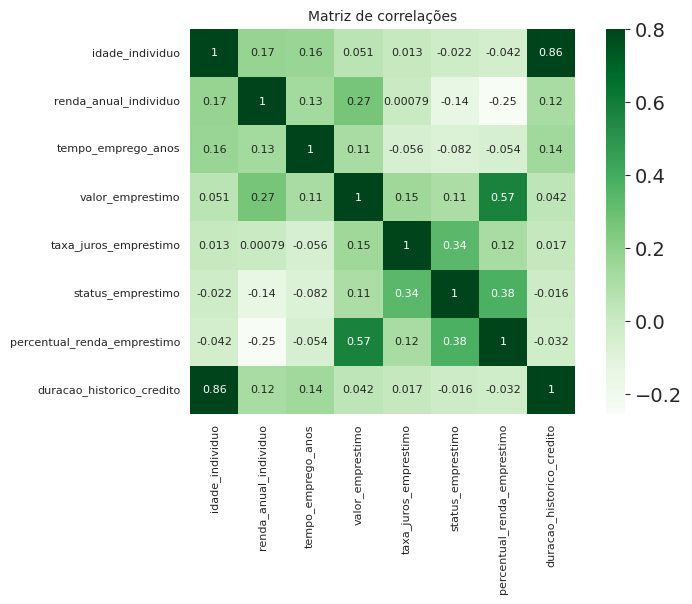

In [18]:
#plota a matriz de correlações
fig, ax = plt.subplots()
fig.set_size_inches(8, 5)
heatmap = sns.heatmap(dados_numericos.corr(), vmax=.8, square=True, annot=True, cmap='Greens', annot_kws={'size': 8})
plt.title('Matriz de correlações', fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=8)
plt.show()

In [19]:
#Exemplo de análise da idade
# IDADE MÁXIMA E MÍNIMA
max_ = dados['idade_individuo'].max()
min_ = dados['idade_individuo'].min()
print(f"Idade máxima {max_}")
print(f"Idade mínima {min_}")

# pessoas com idade entre x e y
def grupo_idade(arr):
    lenarr = len(arr)
    for i in range(0, lenarr-1):
        next = arr[i] + 1
        num_pessoas = dados['idade_individuo'].between(next, arr[i+1]).sum()
        print(f'Idade entre {next} e {arr[i+1]}: Número de pessoas {num_pessoas}')

grupo_idade([0, 18, 26, 36, 46, 54, 80])

Idade máxima 144
Idade mínima 20
Idade entre 1 e 18: Número de pessoas 0
Idade entre 19 e 26: Número de pessoas 17829
Idade entre 27 e 36: Número de pessoas 11834
Idade entre 37 e 46: Número de pessoas 2360
Idade entre 47 e 54: Número de pessoas 399
Idade entre 55 e 80: Número de pessoas 152


In [20]:
#Exemplo de análise da renda
# RENDA MÁXIMA E MÍNIMA
max_ = dados['renda_anual_individuo'].max()
min_ = dados['renda_anual_individuo'].min()

print(f"Renda máxima {max_}")
print(f"Renda mínima {min_}")

# pessoas com renda entre x e y
def grupo_renda(arr):
    lenarr = len(arr)
    for i in range(0, lenarr-1):
        next = arr[i] + 1
        num_pessoas = dados['renda_anual_individuo'].between(next, arr[i+1]).sum()
        print(f'Renda entre {next} e {arr[i+1]}: Número de pessoas {num_pessoas}')

grupo_renda([0, 25000, 50000, 75000, 100000, float('inf')])

Renda máxima 6000000
Renda mínima 4000
Renda entre 1 e 25000: Número de pessoas 2469
Renda entre 25001 e 50000: Número de pessoas 11613
Renda entre 50001 e 75000: Número de pessoas 9622
Renda entre 75001 e 100000: Número de pessoas 4670
Renda entre 100001 e inf: Número de pessoas 4207


In [21]:
#Exemplo de análise dos valores de empréstimo
# VALOR MÍNIMO E MÁXIMO DO EMPRÉSTIMO
max_valor_emprestimo = dados['valor_emprestimo'].max()
min_valor_emprestimo = dados['valor_emprestimo'].min()

print(f"Valor máximo do Empréstimo {max_valor_emprestimo}")
print(f"Valor mínimo do Empréstimo {min_valor_emprestimo}")

# pessoas com empréstimo entre x e y
def grupo_valor_emprestimo(arr):
    lenarr = len(arr)
    for i in range(0, lenarr-1):
        next = arr[i] + 1
        num_pessoas = dados['valor_emprestimo'].between(next, arr[i+1]).sum()
        print(f'Valor do Empréstimo entre {next} e {arr[i+1]}: Número de pessoas {num_pessoas}')

grupo_valor_emprestimo([0, 5000, 10000, 15000, float('inf')])

Valor máximo do Empréstimo 35000
Valor mínimo do Empréstimo 500
Valor do Empréstimo entre 1 e 5000: Número de pessoas 9489
Valor do Empréstimo entre 5001 e 10000: Número de pessoas 12040
Valor do Empréstimo entre 10001 e 15000: Número de pessoas 6123
Valor do Empréstimo entre 15001 e inf: Número de pessoas 4929


In [22]:
#Exemplo de análise dos tipos de imóvel
# Contagem dos tipos de posse de imóvel
level_counts = dados.tipo_posse_imovel.value_counts()

# Gráfico de pizza para tipos de posse de imóvel
fig = px.pie(values=level_counts.values,
             names=level_counts.index,
             color_discrete_sequence=px.colors.sequential.Mint,
             title='Tipo de Posse de Imóvel'
             )

# Atualizações no gráfico
fig.update_traces(textinfo='label+percent+value', textfont_size=10,
                  marker=dict(line=dict(color='#102000', width=0.2)))
fig.update_layout(width=700, height=500)
fig.data[0].marker.line.width = 2
fig.data[0].marker.line.color = 'gray'
fig.show()

In [23]:
#Exemplo de análise dos tipos de empréstimo
# Contagem das classificações de empréstimo
level_counts = dados.classificacao_emprestimo.value_counts()

# Gráfico de pizza para classificações de empréstimo
fig = px.pie(values=level_counts.values,
             names=level_counts.index,
             color_discrete_sequence=px.colors.sequential.Mint,
             title='Classificação do Empréstimo'
             )

# Atualizações no gráfico
fig.update_traces(textinfo='label+percent+value', textfont_size=13,
                  marker=dict(line=dict(color='#102000', width=0.2)))

fig.update_layout(width=700, height=500)
fig.data[0].marker.line.width = 2
fig.data[0].marker.line.color = 'gray'
fig.show()

In [24]:
#Exemplo de análise das finalidades de empréstimo
import plotly.express as px

fig = px.histogram(dados, x='proposito_emprestimo', histnorm='percent', text_auto='.2f',
                   template='presentation', title='Intenção de Empréstimo',
                   color_discrete_sequence=px.colors.sequential.Mint)

fig.update_layout(
    width=700,
    height=500,
    margin=dict(b=100),
    title=dict(
        text='Intenção de Empréstimo',
        y=0.95,
        x=0.5,
        xanchor='center',
        yanchor='top'
    ),
    yaxis_title='Percentual'
)

fig.update_xaxes(
    tickangle=45,
    tickfont=dict(size=12),
    title_standoff=40
)

fig.update_traces(textfont_size=8)

fig.show()

# **Lidando com Outliers e categorizando os dados**

In [25]:
#verificando a quantidade de dados nulos
dados.isnull().sum()

idade_individuo                   0
renda_anual_individuo             0
tipo_posse_imovel                 0
tempo_emprego_anos              895
proposito_emprestimo              0
classificacao_emprestimo          0
valor_emprestimo                  0
taxa_juros_emprestimo          3116
status_emprestimo                 0
percentual_renda_emprestimo       0
historico_inadimplencia           0
duracao_historico_credito         0
dtype: int64

In [26]:
#dropando os valores nulos
dados.dropna(axis=0,inplace=True)

In [27]:
#organizando os índices
dados.reset_index(inplace = True)


#dropa colunas indesejadas se existirem
dados = dados.drop(columns=['index', 'level_0'], errors='ignore')

In [28]:
#conferindo
dados.isnull().sum()

idade_individuo                0
renda_anual_individuo          0
tipo_posse_imovel              0
tempo_emprego_anos             0
proposito_emprestimo           0
classificacao_emprestimo       0
valor_emprestimo               0
taxa_juros_emprestimo          0
status_emprestimo              0
percentual_renda_emprestimo    0
historico_inadimplencia        0
duracao_historico_credito      0
dtype: int64

In [29]:
#verificando os dados que sobraram
tamanho = dados.shape[0]
print(f"Número de linhas do dataset: {tamanho}")

Número de linhas do dataset: 28638


In [30]:
#verificando os dados que sobraram, separando pela variável independente
dados['status_emprestimo'].value_counts()

status_emprestimo
0    22435
1     6203
Name: count, dtype: int64

In [31]:
#novas características após a remoção dos nulos
dados.describe()

,idade_individuo,renda_anual_individuo,tempo_emprego_anos,valor_emprestimo,taxa_juros_emprestimo,status_emprestimo,percentual_renda_emprestimo,duracao_historico_credito
count,28638.00000,28638.00000,28638.00000,28638.00000,28638.00000,28638.00000,28638.00000,28638.00000
mean,27.72722,66649.37188,4.78867,9656.49312,11.03987,0.21660,0.16949,5.79374
std,6.31044,62356.44740,4.15463,6329.68336,3.22937,0.41194,0.10639,4.03848
min,20.00000,4000.00000,0.00000,500.00000,5.42000,0.00000,0.00000,2.00000
25%,23.00000,39480.00000,2.00000,5000.00000,7.90000,0.00000,0.09000,3.00000
50%,26.00000,55956.00000,4.00000,8000.00000,10.99000,0.00000,0.15000,4.00000
75%,30.00000,80000.00000,7.00000,12500.00000,13.48000,0.00000,0.23000,8.00000
max,144.00000,6000000.00000,123.00000,35000.00000,23.22000,1.00000,0.83000,30.00000


In [32]:
# idade máxima 144 (problema)
# tempo de emprego máximo 123 (problema)

<BarContainer object of 57 artists>

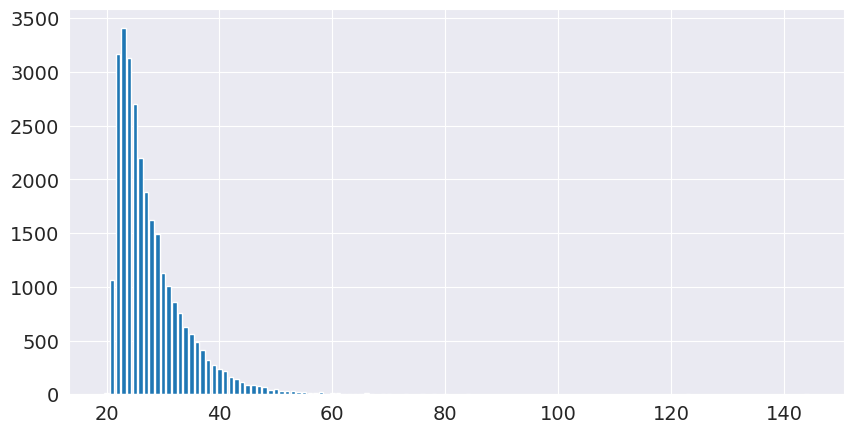

In [33]:
#visualizando as idades
#possível verificar a distorção no gráfico

verti = dados['idade_individuo'].value_counts().values
hori = dados['idade_individuo'].value_counts().index
fig = plt.figure(figsize=(10, 5))
plt.bar(hori, verti)

In [34]:
# verificando quantos dados apresentam a idade maior que 80
(dados['idade_individuo'].value_counts().values > 80).sum()

26

In [35]:
#dropando esses dados
dados = dados.drop(dados[dados['idade_individuo'] > 80].index, axis=0)

In [36]:
#organizando os índices
dados.reset_index(inplace = True)


#dropa colunas indesejadas se existirem
dados = dados.drop(columns=['index', 'level_0'], errors='ignore')

In [37]:
#cria uma nova coluna chamada 'grupo_idade' no DataFrame dados, que categoriza a idade
#dos indivíduos em grupos específicos conforme os intervalos definidos.
dados['grupo_idade'] = pd.cut(dados['idade_individuo'],
                              bins=[19, 26, 36, 46, 56, float('inf')],
                              labels=['idade_19-25', 'idade_26-35', 'idade_36-45', 'idade_46-55', 'idade_>55'])

In [38]:
#cria uma nova coluna chamada 'grupo_renda' no DataFrame dados, que categoriza a renda anual
#dos indivíduos em grupos específicos conforme os intervalos definidos.
dados['grupo_renda'] = pd.cut(dados['renda_anual_individuo'],
                              bins=[0, 25000, 50000, 75000, 100000, float('inf')],
                              labels=['renda_baixa', 'renda_baixa-média', 'renda_média', 'renda_alta-média', 'renda_alta'])


In [39]:
#cria uma nova coluna chamada 'grupo_valor_emprestimo' no DataFrame dados, que
#categoriza o valor do empréstimo em grupos específicos conforme os intervalos definidos.
dados['grupo_valor_emprestimo'] = pd.cut(dados['valor_emprestimo'],
                                         bins=[0, 5000, 10000, 15000, float('inf')],
                                         labels=['emprestimo_pequeno', 'emprestimo_médio', 'emprestimo_grande', 'emprestimo_muito grande'])

In [40]:
#dropando os dados onde o tempo de emprego é maior que 60
dados = dados.drop(dados[dados['tempo_emprego_anos'] > 60].index, axis=0)

In [41]:
#organizando os índices
dados.reset_index(inplace = True)


#dropa colunas indesejadas se existirem
dados = dados.drop(columns=['index', 'level_0'], errors='ignore')

In [42]:
#razão tempo de emprego e o empréstimo
dados['razao_tempo_emprego_emprestimo'] = dados['tempo_emprego_anos'] / dados['valor_emprestimo']

#razão entre taxa de juros e valor do empréstimo
dados['razao_taxa_juros_valor_emprestimo'] = dados['taxa_juros_emprestimo'] / dados['valor_emprestimo']


In [43]:
#organizando as variáveis independentes por tipologia
colunas = ['idade_individuo',
           'renda_anual_individuo',
           'tipo_posse_imovel',
           'tempo_emprego_anos',
           'proposito_emprestimo',
           'classificacao_emprestimo',
           'valor_emprestimo',
           'taxa_juros_emprestimo',
           'percentual_renda_emprestimo',
           'historico_inadimplencia',
           'duracao_historico_credito',
           'grupo_idade',
           'grupo_renda',
           'grupo_valor_emprestimo',
           'razao_tempo_emprego_emprestimo',
           'razao_taxa_juros_valor_emprestimo'
           ]

colunas_numericas = ['renda_anual_individuo', 'idade_individuo', 'tempo_emprego_anos', 'valor_emprestimo', 'taxa_juros_emprestimo', 'duracao_historico_credito', 'percentual_renda_emprestimo', 'razao_tempo_emprego_emprestimo', 'razao_taxa_juros_valor_emprestimo']
colunas_categoricas = ['historico_inadimplencia', 'classificacao_emprestimo', 'tipo_posse_imovel', 'proposito_emprestimo', 'grupo_renda', 'grupo_idade', 'grupo_valor_emprestimo']

# **Processamento dos dados**

In [44]:
#dropando a variável independente para salvar em 'Y', as demais variáveis pertencem a 'X'
X = dados.drop(['status_emprestimo'], axis=1)
Y = dados['status_emprestimo']

In [45]:
#divide o dataset em parte de treino e teste. Neste caso 20% será destinado a teste
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X,Y,test_size=0.2,random_state=12)

In [46]:
#mostra o tamanho dos dataFrames de treino e de teste
print(x_train.shape,x_test.shape)

(22904, 16) (5727, 16)


In [47]:
#organizando os índices
x_train.reset_index(inplace = True)
x_test.reset_index(inplace = True)
y_train.reset_index(drop=True, inplace=True)
y_test.reset_index(drop=True, inplace=True)

#dropa colunas indesejadas se existirem
x_train = x_train.drop(columns=['index', 'level_0'], errors='ignore')
x_test = x_test.drop(columns=['index', 'level_0'], errors='ignore')
y_train = y_train.drop(columns=['index', 'level_0'], errors='ignore')
y_test = y_test.drop(columns=['index', 'level_0'], errors='ignore')

In [48]:
#conferindo as variáveis dependentes
x_train.columns

Index(['idade_individuo', 'renda_anual_individuo', 'tipo_posse_imovel',
       'tempo_emprego_anos', 'proposito_emprestimo',
       'classificacao_emprestimo', 'valor_emprestimo', 'taxa_juros_emprestimo',
       'percentual_renda_emprestimo', 'historico_inadimplencia',
       'duracao_historico_credito', 'grupo_idade', 'grupo_renda',
       'grupo_valor_emprestimo', 'razao_tempo_emprego_emprestimo',
       'razao_taxa_juros_valor_emprestimo'],
      dtype='object')

In [49]:
#transforma as variáveis categóricas em uma representação numérica
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()
ohe.fit(x_train[colunas_categoricas])

OneHotEncoder()

In [50]:
#todas a classificações das variáveis categóricas
ohe.categories_

[array(['historico_inadimplencia', 'sem_historico_inadimplencia'],
       dtype=object),
 array(['classificacao_A', 'classificacao_B', 'classificacao_C',
        'classificacao_D', 'classificacao_E', 'classificacao_F',
        'classificacao_G'], dtype=object),
 array(['aluguel', 'imovel_financiado', 'imovel_outros', 'imovel_proprio'],
       dtype=object),
 array(['fins_consolidacao_debito', 'fins_educacao', 'fins_medicos',
        'fins_negocios', 'fins_pessoais', 'fins_reformas'], dtype=object),
 array(['renda_alta', 'renda_alta-média', 'renda_baixa',
        'renda_baixa-média', 'renda_média'], dtype=object),
 array(['idade_19-25', 'idade_26-35', 'idade_36-45', 'idade_46-55',
        'idade_>55'], dtype=object),
 array(['emprestimo_grande', 'emprestimo_muito grande', 'emprestimo_médio',
        'emprestimo_pequeno'], dtype=object)]

In [51]:
#faz um merge das categorias
merge_ohe_col = np.concatenate((ohe.categories_[0],
                ohe.categories_[1],
                ohe.categories_[2],
                ohe.categories_[3],
                ohe.categories_[4],
                ohe.categories_[5],
                ohe.categories_[6],))

In [52]:
merge_ohe_col

array(['historico_inadimplencia', 'sem_historico_inadimplencia',
       'classificacao_A', 'classificacao_B', 'classificacao_C',
       'classificacao_D', 'classificacao_E', 'classificacao_F',
       'classificacao_G', 'aluguel', 'imovel_financiado', 'imovel_outros',
       'imovel_proprio', 'fins_consolidacao_debito', 'fins_educacao',
       'fins_medicos', 'fins_negocios', 'fins_pessoais', 'fins_reformas',
       'renda_alta', 'renda_alta-média', 'renda_baixa',
       'renda_baixa-média', 'renda_média', 'idade_19-25', 'idade_26-35',
       'idade_36-45', 'idade_46-55', 'idade_>55', 'emprestimo_grande',
       'emprestimo_muito grande', 'emprestimo_médio',
       'emprestimo_pequeno'], dtype=object)

In [53]:
# aplica a codificação one-hot nas colunas categóricas do conjunto de dados de treinamento e teste.
#A codificação one-hot é uma técnica usada para converter variáveis categóricas em um formato que pode ser fornecido a algoritmos de ML
ohe_data_train = pd.DataFrame(ohe.transform(x_train[colunas_categoricas]).toarray(), columns=merge_ohe_col)
ohe_data_test = pd.DataFrame(ohe.transform(x_test[colunas_categoricas]).toarray(),columns=merge_ohe_col)

In [54]:
#Adiciona as colunas das categorias convertidas e dropa as categorias originais
#que estavam em formato de texto
X_new_train = pd.concat([ohe_data_train, x_train], axis=1)
X_new_train = X_new_train.drop(colunas_categoricas, axis=1)


X_new_test = pd.concat([ohe_data_test, x_test], axis=1)
X_new_test = X_new_test.drop(colunas_categoricas, axis=1)

In [55]:
X_new_train.shape

(22904, 41)

In [56]:
#copia dos dados originais antes da padronização, por segurança e possíveis análises
X_new_train_original = X_new_train.copy()
X_new_test_original = X_new_test.copy()

In [57]:
#sample_data = X_new_train_original

# Exporta a amostra de dados para um arquivo CSV
#sample_data.to_csv('sample_data.csv', index=False)

In [58]:
#faz a standarização dos dados
from sklearn.preprocessing import StandardScaler


scaler_normal = StandardScaler()
X_new_train.loc[:, colunas_numericas] = scaler_normal.fit_transform(X_new_train.loc[:, colunas_numericas])
X_new_test.loc[:, colunas_numericas] = scaler_normal.transform(X_new_test.loc[:, colunas_numericas])


In [59]:
#verifica os novos dados standarizados
X_new_test.head()

,sem_historico_inadimplencia,classificacao_A,classificacao_B,classificacao_C,classificacao_D,classificacao_E,classificacao_F,classificacao_G,aluguel,imovel_financiado,imovel_outros,imovel_proprio,fins_consolidacao_debito,fins_educacao,fins_medicos,fins_negocios,fins_pessoais,fins_reformas,renda_alta,renda_alta-média,renda_baixa,renda_baixa-média,renda_média,idade_19-25,idade_26-35,idade_36-45,idade_46-55,idade_>55,emprestimo_grande,emprestimo_muito grande,emprestimo_médio,emprestimo_pequeno,idade_individuo,renda_anual_individuo,tempo_emprego_anos,valor_emprestimo,taxa_juros_emprestimo,percentual_renda_emprestimo,duracao_historico_credito,razao_tempo_emprego_emprestimo,razao_taxa_juros_valor_emprestimo
0,1.00000,1.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000,0.00000,1.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000,1.18171,-0.00623,-0.19283,-1.05271,-1.55638,-1.12339,0.29664,0.53087,0.07667
1,1.00000,0.00000,0.00000,0.00000,1.00000,0.00000,0.00000,0.00000,1.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000,0.00000,0.00000,1.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000,0.00000,1.18171,-0.65535,-0.44065,-0.19741,1.19522,0.75747,0.54397,-0.38092,-0.04953
2,0.00000,0.00000,0.00000,0.00000,1.00000,0.00000,0.00000,0.00000,1.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000,0.00000,0.00000,1.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000,0.00000,0.69519,-0.59893,-0.19283,-0.57754,1.55467,0.00513,1.03862,-0.09182,0.43559
3,0.00000,0.00000,0.00000,1.00000,0.00000,0.00000,0.00000,0.00000,1.00000,0.00000,0.00000,0.00000,0.00000,1.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000,1.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000,0.00000,0.00000,-0.44003,-0.09514,-0.93628,1.32313,0.67465,1.13364,-0.93999,-0.66262,-0.60803
4,1.00000,0.00000,1.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000,0.00000,0.00000,0.00000,1.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000,0.00000,0.00000,0.00000,1.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000,0.69519,-0.83601,0.55062,-1.08439,-0.01945,-0.46509,0.79130,1.62057,1.10508


In [60]:
#verificando as variáveis que irão treinar o modelo
print(X_new_test.columns)

Index(['sem_historico_inadimplencia', 'classificacao_A', 'classificacao_B',
       'classificacao_C', 'classificacao_D', 'classificacao_E',
       'classificacao_F', 'classificacao_G', 'aluguel', 'imovel_financiado',
       'imovel_outros', 'imovel_proprio', 'fins_consolidacao_debito',
       'fins_educacao', 'fins_medicos', 'fins_negocios', 'fins_pessoais',
       'fins_reformas', 'renda_alta', 'renda_alta-média', 'renda_baixa',
       'renda_baixa-média', 'renda_média', 'idade_19-25', 'idade_26-35',
       'idade_36-45', 'idade_46-55', 'idade_>55', 'emprestimo_grande',
       'emprestimo_muito grande', 'emprestimo_médio', 'emprestimo_pequeno',
       'idade_individuo', 'renda_anual_individuo', 'tempo_emprego_anos',
       'valor_emprestimo', 'taxa_juros_emprestimo',
       'percentual_renda_emprestimo', 'duracao_historico_credito',
       'razao_tempo_emprego_emprestimo', 'razao_taxa_juros_valor_emprestimo'],
      dtype='object')


# **Modelo de Regressão Logística**

In [61]:
# Remove os nomes das colunas convertendo para arrays NumPy
X_new_train_values = X_new_train.values
X_new_test_values = X_new_test.values

In [62]:
#importando o modelo
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_new_train_values, y_train)

LogisticRegression()

In [63]:
#importanto as métricas
from sklearn.metrics import precision_score, accuracy_score, recall_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

In [64]:
#conferindo a quantidade de dados e variáveis dependentes ou preditoras de treino
X_new_train_values.shape

(22904, 41)

In [65]:
#conferindo a quantidade de dados e variáveis dependentes ou preditoras de teste
X_new_test_values.shape

(5727, 41)

In [66]:
#conferindo a quantidade de dados de treino para a variável indepentente ou predita
y_train.shape

(22904,)

In [67]:
#conferindo a quantidade de dados de teste para a variável indepentente ou predita
y_test.shape

(5727,)

In [68]:
#testando o modelo no dataSet de teste
predicoes = model.predict(X_new_test_values)

In [69]:
# Acurácia
accuracy = accuracy_score(y_test, predicoes)
print(f"Acurácia: {accuracy}")

Acurácia: 0.8721843897328444


A proporção de previsões corretas entre o total de previsões. É uma boa métrica quando as classes estão balanceadas. Nesse caso deve-se tomar cuidado pois as classes não são balanceadas.

In [70]:
#desbalanceamento das classes
y_test.value_counts()

status_emprestimo
0    4483
1    1244
Name: count, dtype: int64

In [71]:
# Matriz de Confusão
conf_matrix = confusion_matrix(y_test, predicoes)
print(f"Matrix de confusão:\n{conf_matrix}")

Matrix de confusão:
[[4273  210]
 [ 522  722]]


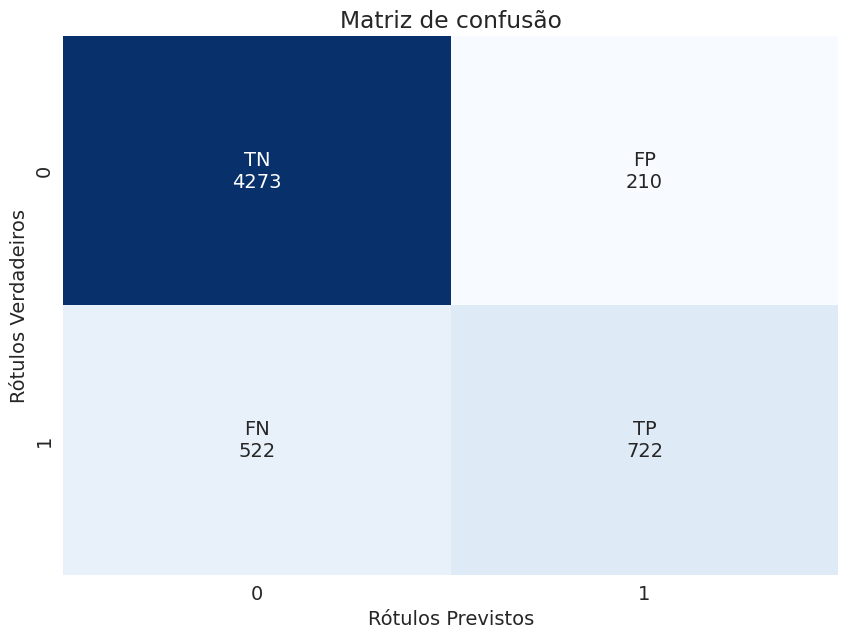

In [72]:
# Criando o gráfico da matriz de confusão
labels = [['TN', 'FP'], ['FN', 'TP']]
annot = [[f'{labels[i][j]}\n{conf_matrix[i][j]}' for j in range(2)] for i in range(2)]

plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=annot, fmt='', cmap='Blues', cbar=False, xticklabels=True, yticklabels=True)
plt.xlabel('Rótulos Previstos')
plt.ylabel('Rótulos Verdadeiros')
plt.title('Matriz de confusão')
plt.show()

Matriz de Confusão:

[TN  FP]

[FN  TP]

TN (Verdadeiros Negativos): Previsões corretas onde o modelo identificou clientes adimplentes corretamente.

FP (Falsos Positivos): Previsões incorretas onde o modelo identificou clientes adimplentes como inadimplentes.

FN (Falsos Negativos): Previsões incorretas onde o modelo identificou clientes inadimplentes como adimplentes.

TP (Verdadeiros Positivos): Previsões corretas onde o modelo identificou clientes inadimplentes corretamente.

In [73]:
# Relatório de Classificação
class_report = classification_report(y_test, predicoes)
print(f"Resultado da classificação:\n{class_report}")

Resultado da classificação:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      4483
           1       0.77      0.58      0.66      1244

    accuracy                           0.87      5727
   macro avg       0.83      0.77      0.79      5727
weighted avg       0.87      0.87      0.87      5727



Precisão: A precisão do modelo é a proporção de previsões positivas corretas em relação ao total de previsões positivas feitas pelo modelo ou vice-versa. Exemplo: TP/(TP+FP)

Recall: O recall do modelo é a proporção de previsões positivas corretas (verdadeiros positivos) em relação ao total de casos reais positivos (verdadeiros positivos + falsos negativos) ou vice-versa. Exemplo: TP/(TP+FN)

F1-score: O F1-score é a média harmônica da precisão e do recall, e fornece um equilíbrio entre as duas métricas.

In [74]:
# AUC-ROC
y_prob = model.predict_proba(X_new_test_values)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC AUC: {roc_auc}")

ROC AUC: 0.8852409925886504


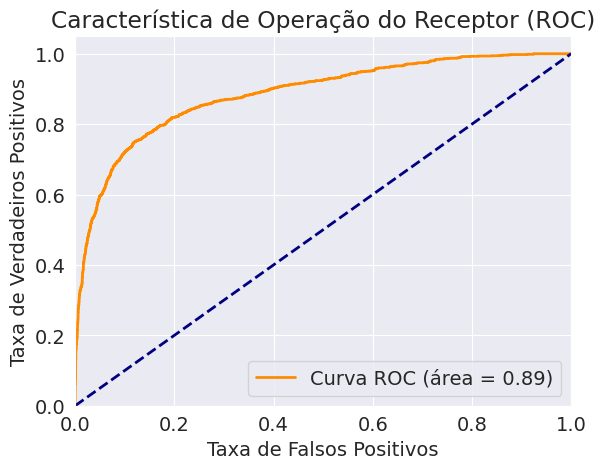

In [75]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (área = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Característica de Operação do Receptor (ROC)')
plt.legend(loc="lower right")
plt.show()

Definição: A AUC é a área sob a curva ROC. É uma métrica que resume a performance do modelo em um único valor.

A AUC varia de 0 a 1:

0.5: Indica um modelo aleatório, sem capacidade de discriminação entre as classes.

1: Indica um modelo perfeito, que classifica corretamente todos os exemplos.

0: Indica um modelo completamente errado, que classifica todos os exemplos incorretamente.
Valores entre 0.5 e 1: Indicam a qualidade do modelo em discriminar entre as classes. Quanto mais próximo de 1, melhor o modelo.

In [76]:
# Acessa os coeficientes das variáveis
coeficientes = model.coef_

# Mostra os coeficientes atribuídos a cada variável
for nome_variavel, coeficiente in zip(X_new_train.columns, coeficientes[0]):
    print(f'{nome_variavel}: {coeficiente}')

sem_historico_inadimplencia: 0.006742316140278479
classificacao_A: -1.6682411506355945
classificacao_B: -1.6634816970587214
classificacao_C: -1.5159287598723117
classificacao_D: 0.48856229434431214
classificacao_E: 0.6347185011440172
classificacao_F: 0.7659855395825051
classificacao_G: 2.5640420698018347
aluguel: 0.9346893829792211
imovel_financiado: 0.06746912318674195
imovel_outros: 0.47300607212421003
imovel_proprio: -1.8695077809841543
fins_consolidacao_debito: 0.42966916869160926
fins_educacao: -0.4434236696762894
fins_medicos: 0.24320091838177388
fins_negocios: -0.7681943922474529
fins_pessoais: -0.25738591019901497
fins_reformas: 0.4017906823553844
renda_alta: 0.36935077814313905
renda_alta-média: -0.171776127841874
renda_baixa: 0.005497695597152748
renda_baixa-média: -0.44740700774378456
renda_média: -0.1500085408486323
idade_19-25: 0.10652130253913661
idade_26-35: -0.023740853550205936
idade_36-45: -0.12693096162134596
idade_46-55: -0.03182341621081272
idade_>55: -0.3183692738

**Coeficiente positivo**: Indica que um aumento na variável correspondente está associado a uma maior probabilidade de o cliente ser classificado como inadimplente (1). Por exemplo, se a variável é a taxa de juros do empréstimo, um coeficiente positivo significa que um aumento na taxa de juros está associado a uma maior probabilidade de inadimplência.

**Coeficiente negativo**: Indica que um aumento na variável correspondente está associado a uma menor probabilidade de o cliente ser classificado como inadimplente (1). Por exemplo, se a variável é o tempo de emprego do indivíduo, um coeficiente negativo significa que um aumento no tempo de emprego está associado a uma menor probabilidade de inadimplência.

In [77]:
probabilidades = model.predict_proba(X_new_test_values)[:, 1]

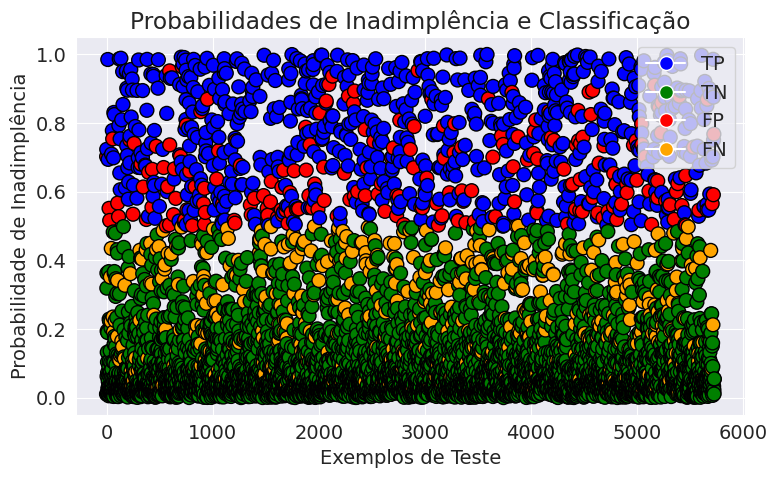

In [78]:
# Comparação com os valores reais
y_test_ = y_test.values

#cores para cada categoria
colors = []
for i in range(len(y_test)):
    if y_test_[i] == 1 and predicoes[i] == 1:
        colors.append('blue')  # Verdadeiros Positivos (TP)
    elif y_test_[i] == 0 and predicoes[i] == 0:
        colors.append('green')  # Verdadeiros Negativos (TN)
    elif y_test_[i] == 0 and predicoes[i] == 1:
        colors.append('red')  # Falsos Positivos (FP)
    elif y_test_[i] == 1 and predicoes[i] == 0:
        colors.append('orange')  # Falsos Negativos (FN)

#cria o gráfico
plt.figure(figsize=(8, 5))

#plota os dados
plt.scatter(range(len(probabilidades)), probabilidades, c=colors, edgecolor='k', s=100)
plt.title('Probabilidades de Inadimplência e Classificação')
plt.xlabel('Exemplos de Teste')
plt.ylabel('Probabilidade de Inadimplência')

#adiciona a legenda
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='TP'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10, label='TN'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='FP'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=10, label='FN')
]
plt.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

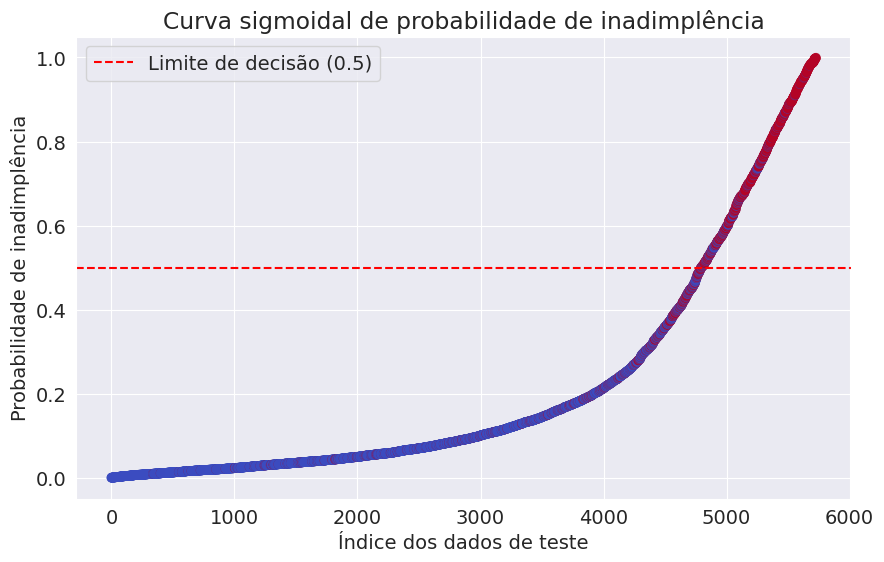

In [79]:
# Ordenando as probabilidades e os rótulos para plotagem
sorted_indices = np.argsort(probabilidades)
probabilidades_sorted = probabilidades[sorted_indices]
y_test_sorted = y_test.values[sorted_indices]

# Plotando a curva sigmoidal
plt.figure(figsize=(10, 6))
plt.scatter(np.arange(len(y_test)), probabilidades_sorted, c=y_test_sorted, cmap='coolwarm', alpha=0.6)
plt.axhline(y=0.5, color='r', linestyle='--', label='Limite de decisão (0.5)')
plt.xlabel('Índice dos dados de teste')
plt.ylabel('Probabilidade de inadimplência')
plt.title('Curva sigmoidal de probabilidade de inadimplência')
plt.legend()
plt.grid(True)
plt.show()

# **Exemplo para predição de novo cliente**

In [80]:
exemplo_inadimplente = [
    1.0,  # sem_historico_inadimplencia
    #####
    0.0,  # classificacao_A
    0.0,  # classificacao_B
    0.0,  # classificacao_C
    0.0,  # classificacao_D
    0.0,  # classificacao_E
    1.0,  # classificacao_F
    0.0,  # classificacao_G
    #####
    1.0,  # aluguel
    0.0,  # imovel_financiado
    0.0,  # imovel_outros
    0.0,  # imovel_proprio
    #####
    0.0,  # fins_consolidacao_debito
    0.0,  # fins_educacao
    0.0,  # fins_medicos
    0.0,  # fins_negocios
    1.0,  # fins_pessoais
    0.0,  # fins_reformas
    #####
    0.0,  # renda_alta
    0.0,  # renda_alta-média
    0.0,  # renda_baixa
    1.0,  # renda_baixa-média
    0.0,  # renda_média
    #####
    1.0,  # idade_19-25
    0.0,  # idade_26-35
    0.0,  # idade_36-45
    0.0,  # idade_46-55
    0.0,  # idade_>55
    #####
    0.0,  # emprestimo_grande
    0.0,  # emprestimo_muito grande
    1.0,  # emprestimo_médio
    0.0,  # emprestimo_pequeno
    #####
    23,   # idade_individuo
    26000,  # renda_anual_individuo
    5.0,   # tempo_emprego_anos
    6000,  # valor_emprestimo
    6.62,  # taxa_juros_emprestimo
    0.23,  # percentual_renda_emprestimo
    2,     # duracao_historico_credito
    #####
    0.0008333333333333334,  # razao_tempo_emprego_emprestimo
    0.0011033333333333333  # razao_taxa_juros_valor_emprestimo
]


In [81]:
exemplo_adimplente = [
    1.0,  # sem_historico_inadimplencia
    #####
    1.0,  # classificacao_A
    0.0,  # classificacao_B
    0.0,  # classificacao_C
    0.0,  # classificacao_D
    0.0,  # classificacao_E
    0.0,  # classificacao_F
    0.0,  # classificacao_G
    #####
    0.0,  # aluguel
    0.0,  # imovel_financiado
    0.0,  # imovel_outros
    1.0,  # imovel_proprio
    #####
    0.0,  # fins_consolidacao_debito
    1.0,  # fins_educacao
    0.0,  # fins_medicos
    0.0,  # fins_negocios
    0.0,  # fins_pessoais
    0.0,  # fins_reformas
    #####
    1.0,  # renda_alta
    0.0,  # renda_alta-média
    0.0,  # renda_baixa
    0.0,  # renda_baixa-média
    0.0,  # renda_média
    #####
    0.0,  # idade_19-25
    1.0,  # idade_26-35
    0.0,  # idade_36-45
    0.0,  # idade_46-55
    0.0,  # idade_>55
    #####
    0.0,  # emprestimo_grande
    0.0,  # emprestimo_muito grande
    1.0,  # emprestimo_médio
    0.0,  # emprestimo_pequeno
    #####
    34,   # idade_individuo
    85000,  # renda_anual_individuo
    10.0,   # tempo_emprego_anos
    6000,  # valor_emprestimo
    4.5,    # taxa_juros_emprestimo
    0.07,   # percentual_renda_emprestimo
    5,      # duracao_historico_credito
    #####
    0.0016666666666667,   # razao_tempo_emprego_emprestimo
    0.00075,  # razao_taxa_juros_valor_emprestimo
]

In [82]:
#colocando os novos dados na padronização criada anteriormente
colunas_pos_tratamento = ['sem_historico_inadimplencia', 'classificacao_A', 'classificacao_B',
       'classificacao_C', 'classificacao_D', 'classificacao_E',
       'classificacao_F', 'classificacao_G', 'aluguel', 'imovel_financiado',
       'imovel_outros', 'imovel_proprio', 'fins_consolidacao_debito',
       'fins_educacao', 'fins_medicos', 'fins_negocios', 'fins_pessoais',
       'fins_reformas', 'renda_alta', 'renda_alta-média', 'renda_baixa',
       'renda_baixa-média', 'renda_média', 'idade_19-25', 'idade_26-35',
       'idade_36-45', 'idade_46-55', 'idade_>55', 'emprestimo_grande',
       'emprestimo_muito grande', 'emprestimo_médio', 'emprestimo_pequeno',
       'idade_individuo', 'renda_anual_individuo', 'tempo_emprego_anos',
       'valor_emprestimo', 'taxa_juros_emprestimo',
       'percentual_renda_emprestimo', 'duracao_historico_credito',
       'razao_tempo_emprego_emprestimo',
       'razao_taxa_juros_valor_emprestimo']

In [83]:
#cria cópias dos dados originais
X_inadimplente = pd.DataFrame([exemplo_inadimplente], columns=colunas_pos_tratamento)
X_adimplente = pd.DataFrame([exemplo_adimplente], columns=colunas_pos_tratamento)

In [84]:
#faz a standarização dos dados para as colunas numéricas
X_inadimplente.loc[:, colunas_numericas] = scaler_normal.transform(X_inadimplente.loc[:, colunas_numericas])
X_adimplente.loc[:, colunas_numericas] = scaler_normal.transform(X_adimplente.loc[:, colunas_numericas])

In [85]:
#probabilidade de inadimplência
probabilidade_exemplo_inadimplente = model.predict_proba(X_inadimplente)[:,1]
print(probabilidade_exemplo_inadimplente)

[0.6729225]


In [86]:
#probabilidade de inadimplência
probabilidade_exemplo_adimplente = model.predict_proba(X_adimplente)[:,1]
print(probabilidade_exemplo_adimplente)

[0.00116277]
